<a href="https://colab.research.google.com/github/swathi942/Job-Acceptance-Prediction/blob/main/HR_job_acceptance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("HR_Job_Placement_Dataset.csv")

print(df.head())
print(df.columns)

   age_years  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0         27    Male       65.061656       83.842578          75.856526   
1         24    Male       67.885626       64.973305          73.093588   
2         33  Female       73.892471       68.834121          90.196460   
3         31    Male       74.145568       76.255126          75.586731   
4         28    Male       60.475937       65.786336          80.801010   

    degree_specialization  technical_score  aptitude_score  \
0        Computer Science        58.221909       89.566305   
1             Electronics        71.927978       54.591971   
2  Information Technology        72.445041       58.587088   
3              Mechanical        78.855676       61.022065   
4  Information Technology        68.286776       65.713731   

   communication_score  skills_match_percentage  ...  expected_ctc_lpa  \
0            64.474484                79.548913  ...          5.805850   
1            61.077306      

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df['status'] = df['status'].map({
    'Placed': 1,
    'Not Placed': 0
})

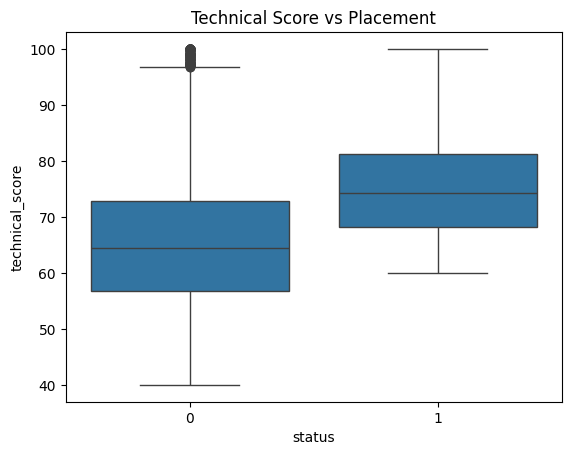

In [ ]:
sns.boxplot(x='status', y='technical_score', data=df)
plt.title("Technical Score vs Placement")
plt.show()


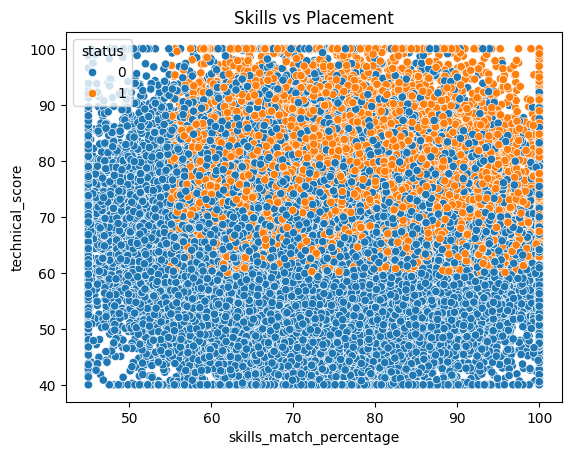

In [ ]:
sns.scatterplot(
    x='skills_match_percentage',
    y='technical_score',
    hue='status',
    data=df
)
plt.title("Skills vs Placement")
plt.show()



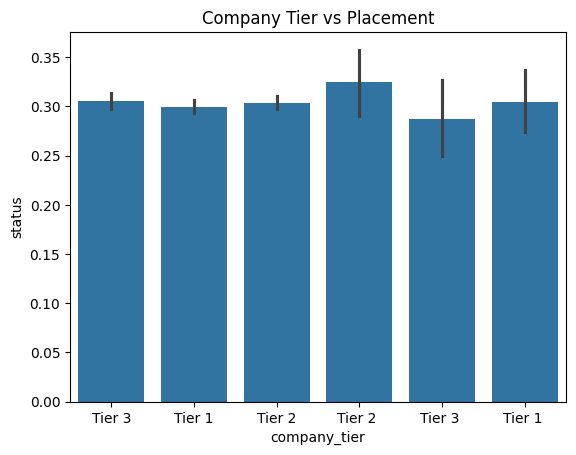

In [ ]:
sns.barplot(x='company_tier', y='status', data=df)
plt.title("Company Tier vs Placement")
plt.show()




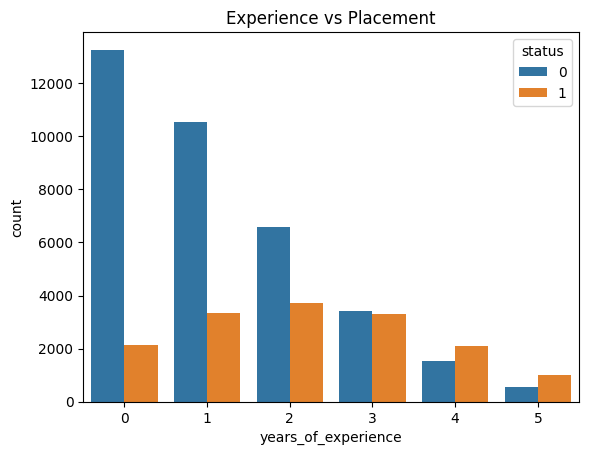

In [ ]:
sns.countplot(x='years_of_experience', hue='status', data=df)
plt.title("Experience vs Placement")
plt.show()



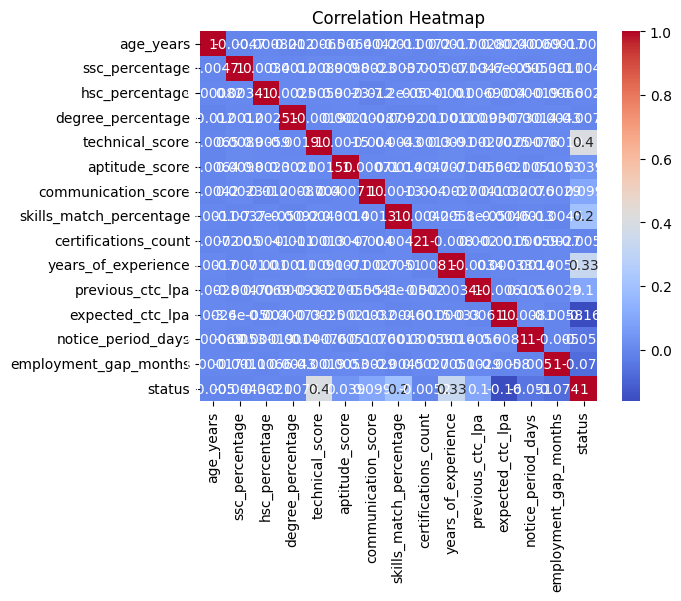

In [ ]:
num_df = df.select_dtypes(include='number')

sns.heatmap(num_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
def exp_cat(x):
    if x == 0:
        return "Fresher"
    elif x <= 3:
        return "Junior"
    else:
        return "Senior"

df['experience_category'] = df['years_of_experience'].apply(exp_cat)

In [ ]:
def acad(x):
    if x < 40:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

df['academic_performance'] = df['aptitude_score'].apply(acad)



In [ ]:
def skill(x):
    if x < 40:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

df['skills_level'] = df['skills_match_percentage'].apply(skill)



In [ ]:
df['interview_score'] = (
    df['technical_score'] + df['communication_score']
) / 2

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8920388349514563
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7128
           1       0.86      0.78      0.82      3172

    accuracy                           0.89     10300
   macro avg       0.88      0.86      0.87     10300
weighted avg       0.89      0.89      0.89     10300



In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [ ]:
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status,experience_category,academic_performance,skills_level,interview_score
0,27,1,65.061656,83.842578,75.856526,0,58.221909,89.566305,64.474484,79.548913,...,0,15.0,0,18.0,0,0,1,0,0,61.348197
1,24,1,67.885626,64.973305,73.093588,1,71.927978,54.591971,61.077306,73.316134,...,1,0.0,0,0.0,0,0,0,1,0,66.502642
2,33,0,73.892471,68.834121,90.196460,2,72.445041,58.587088,79.494739,75.466980,...,0,0.0,0,3.0,0,1,1,1,0,75.969890
3,31,1,74.145568,76.255126,75.586731,3,78.855676,61.022065,53.740386,73.676449,...,0,0.0,1,6.0,1,0,0,1,0,66.298031
4,28,1,60.475937,65.786336,80.801010,2,68.286776,65.713731,61.438314,88.994847,...,0,0.0,0,3.0,1,0,0,1,0,64.862545


In [ ]:
df.tail()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status,experience_category,academic_performance,skills_level,interview_score
51495,24,0,65.747180,72.063946,72.247881,1,55.923057,73.208032,69.108895,63.992488,...,1,0.0,0,3.0,1,0,0,0,1,62.515976
51496,22,1,61.921459,66.729203,55.000000,4,69.525121,70.245612,54.959868,88.514232,...,0,60.0,0,0.0,0,1,1,0,0,62.242495
51497,30,1,75.578202,75.717623,75.048301,2,73.073239,58.870416,71.219454,79.326789,...,0,0.0,0,12.0,1,1,1,1,0,72.146347
51498,29,0,77.327209,56.629227,69.735374,3,48.270078,61.171900,71.650243,76.318681,...,0,0.0,1,0.0,1,0,0,1,0,59.960160
51499,26,0,60.228166,73.374538,70.198897,2,76.417668,77.979750,50.369813,88.475880,...,0,60.0,0,0.0,0,1,1,0,0,63.393740


In [ ]:
df.to_csv("HR_job_prediction_cleaned.csv", index=False)
print("CSV saved successfully!")


CSV saved successfully!


In [ ]:
from google.colab import files
files.download("HR_job_prediction_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

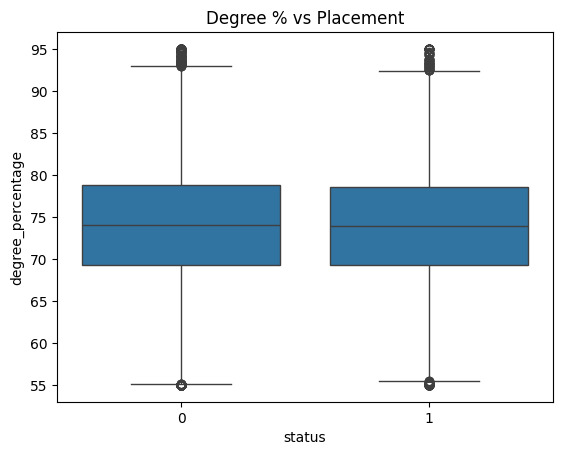

In [ ]:
sns.boxplot(x='status', y='degree_percentage', data=df)
plt.title("Degree % vs Placement")
plt.show()

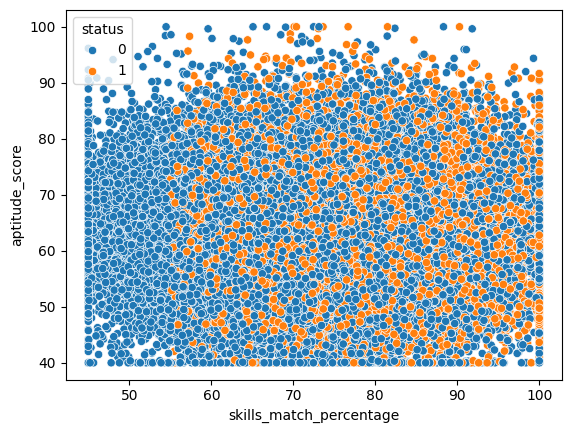

In [ ]:
sns.scatterplot(x='skills_match_percentage',
                y='aptitude_score',
                hue='status', data=df)
plt.show()

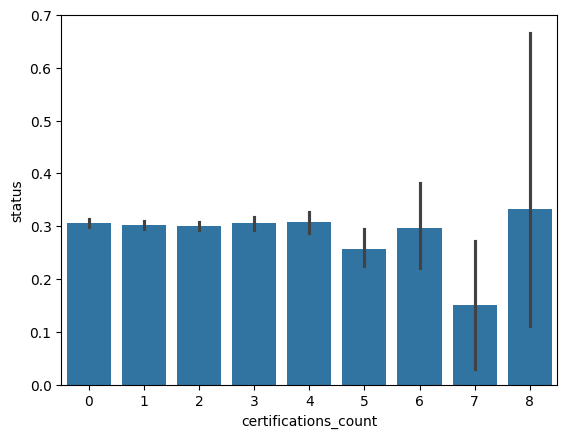

In [ ]:
sns.barplot(x='certifications_count', y='status', data=df)
plt.show()

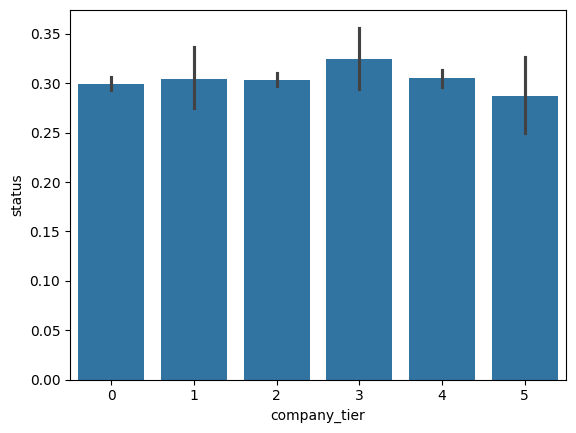

In [ ]:
sns.barplot(x='company_tier', y='status', data=df)
plt.show()

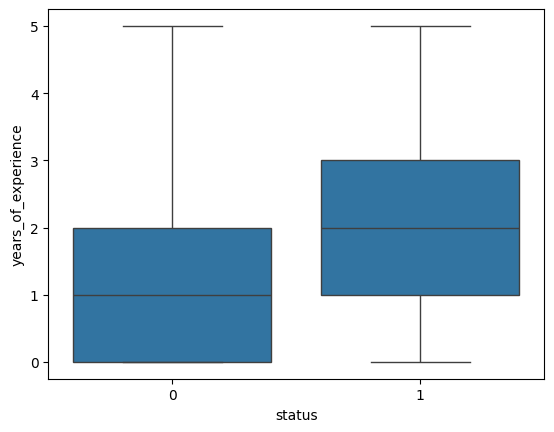

In [ ]:
sns.boxplot(x='status', y='years_of_experience', data=df)
plt.show()

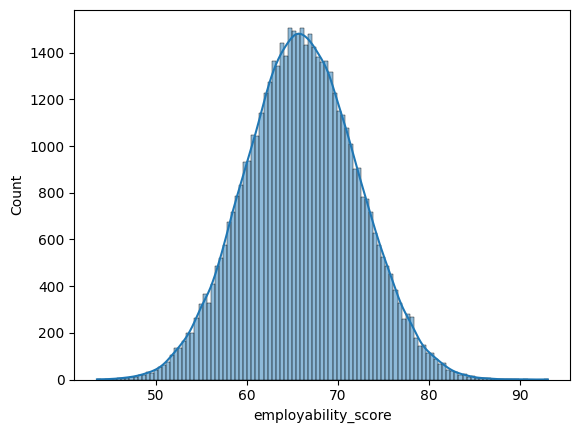

In [ ]:
df['employability_score'] = (
    df['aptitude_score'] + df['technical_score'] + df['communication_score']
)/3

sns.histplot(df['employability_score'], kde=True)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X = df[['degree_percentage', 'skills_match_percentage',
        'aptitude_score', 'technical_score',
        'communication_score', 'years_of_experience',
        'certifications_count']]

y = df['status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7944660194174757
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      7128
           1       0.70      0.57      0.63      3172

    accuracy                           0.79     10300
   macro avg       0.76      0.73      0.74     10300
weighted avg       0.79      0.79      0.79     10300



In [ ]:
print(df.columns)

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status', 'experience_category', 'academic_performance', 'skills_level',
       'interview_score', 'employability_score'],
      dtype='object')
